# Lab MQTT — 01. Topic Analysis

Reads the four `topicdf_*.pkl` files and extracts the **topic lists** used by the MQTT
client (notebook `02_mqtt_collector.py`) to subscribe to the public brokers **without a
root-level `#`** (Mosquitto/HiveMQ/EMQX forbid it).

**Main outputs:**
- `top_root_topics.csv` — top roots + broker frequency
- `top_level_words.csv` — most frequent words at any level
- `subscription_list.json` — final list of subscribe **filter topics** (QoS 2)
- a few summary figures (depth/length CDF, top-root bar chart), paper-style

In [5]:
import pandas as pd
import re
import json
import gc
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = Path("./")  # change if the .pkl are elsewhere
OUT_DIR  = Path("./outputs")
OUT_DIR.mkdir(exist_ok=True)

FILES = sorted(DATA_DIR.glob("topicdf_*.pkl"))
print("Found:", FILES)

Found: [PosixPath('topicdf_1.pkl'), PosixPath('topicdf_2.pkl'), PosixPath('topicdf_3.pkl'), PosixPath('topicdf_4.pkl')]


## 1. Quick inspection

In [6]:
# Open only the first file to understand the structure
df = pd.read_pickle(FILES[0], compression="gzip")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head(2)

Shape: (1051, 1)
Columns: ['topic_list']


,topic_list
0,"{'P_VALVE_CONTROL_SIM': {'total': 846, 'leadin..."
1,{'ActiveMQ/Advisory/MasterBroker': {'total': 8...


In [7]:
# One row = one broker. Column topic_list is a STRING holding a Python dict like:
#   { "<topic>": {"total": N, "topic_depth": K, "topic_length": L, ...}, ... }
# The dict can be huge (some brokers have >500k topics), so we do not literal_eval
# the whole dataset: we use regex to pull only what we need.
raw = df.iloc[1]['topic_list']
print("String length:", len(raw))
print("First 400 chars:\n", raw[:400])

String length: 3930
First 400 chars:
 {'ActiveMQ/Advisory/MasterBroker': {'total': 8, 'leading_forward_slash': 1, 'empty_spaces_rate': 1, 'forbidden_symbols_rate': 1, 'non_ascii_characters': 1, 'empty_level': 1, 'topic_depth': 3, 'topic_length': 30, 'vwr_en': 0.33, 'vwr_other': 0.0, 'retained': 0, 'duplicated': 0, 'qos_distribution': {1: 8}, 'payload_length_distribution': {0: 8}, 'json_type_distribution': {}, 'not_json_type_distributi


## 2. Efficient regex extraction

To avoid memory issues (some rows are >80 MB strings) we extract `topic_depth`,
`topic_length`, `total` and the topic names directly with regex.

In [8]:
# Top-level dict keys look like   '<topic>': {'total': ...
key_pat    = re.compile(r"'([^']+)': \{'total':")
depth_pat  = re.compile(r"'topic_depth': (\d+)")
length_pat = re.compile(r"'topic_length': (\d+)")

all_topics_counter      = Counter()  # <full topic>: # occurrences (on how many brokers it appears)
root_by_broker_counter  = Counter()  # <root>: # distinct brokers
level_by_broker_counter = Counter()  # <level word>: # distinct brokers
depth_counter  = Counter()           # depth -> #topics
length_counter = Counter()           # length -> #topics

broker_topic_counts = []  # how many topics each broker has
total_brokers = 0

for f in FILES:
    df = pd.read_pickle(f, compression="gzip")
    print(f"  {f.name}: {len(df)} brokers")
    for raw in df['topic_list']:
        total_brokers += 1
        topic_names = key_pat.findall(raw)
        broker_topic_counts.append(len(topic_names))
        broker_roots, broker_levels = set(), set()
        for t in topic_names:
            all_topics_counter[t] += 1
            if t.startswith('$SYS'):
                continue  # ignore system topics, as in the paper
            non_empty = [p for p in t.split('/') if p]
            if non_empty:
                broker_roots.add(non_empty[0])
            for p in non_empty:
                broker_levels.add(p)
        for r in broker_roots:  root_by_broker_counter[r] += 1
        for lv in broker_levels: level_by_broker_counter[lv] += 1
        # depth/length per topic
        for d in depth_pat.findall(raw):  depth_counter[int(d)] += 1
        for l in length_pat.findall(raw): length_counter[int(l)] += 1
    del df
    gc.collect()

print(f"\nBrokers analyzed:  {total_brokers}")
print(f"Distinct topics:   {len(all_topics_counter):,}")
print(f"Distinct roots (no $SYS): {len(root_by_broker_counter):,}")
print(f"Distinct level words: {len(level_by_broker_counter):,}")

  topicdf_1.pkl: 1051 brokers
  topicdf_2.pkl: 1052 brokers
  topicdf_3.pkl: 1052 brokers
  topicdf_4.pkl: 1052 brokers

Brokers analyzed:  4207
Distinct topics:   2,818,854
Distinct roots (no $SYS): 184,635
Distinct level words: 1,812,686


## 3. Top root topics (paper-style: % of brokers where they appear)

In [9]:
TOP_N = 30
rows = [(name, c, 100*c/total_brokers) for name, c in root_by_broker_counter.most_common(TOP_N)]
top_roots = pd.DataFrame(rows, columns=['root', 'n_brokers', 'pct_brokers'])
top_roots.to_csv(OUT_DIR / "top_root_topics.csv", index=False)
top_roots

,root,n_brokers,pct_brokers
0,ActiveMQ,395,9.389113
1,gateway,257,6.108866
2,tasmota,211,5.015450
3,tele,210,4.991681
4,application,205,4.872831
5,homeassistant,191,4.540052
6,MECO,175,4.159734
7,test,114,2.709769
8,cmnd,101,2.400761
9,zigbee2mqtt,95,2.258141


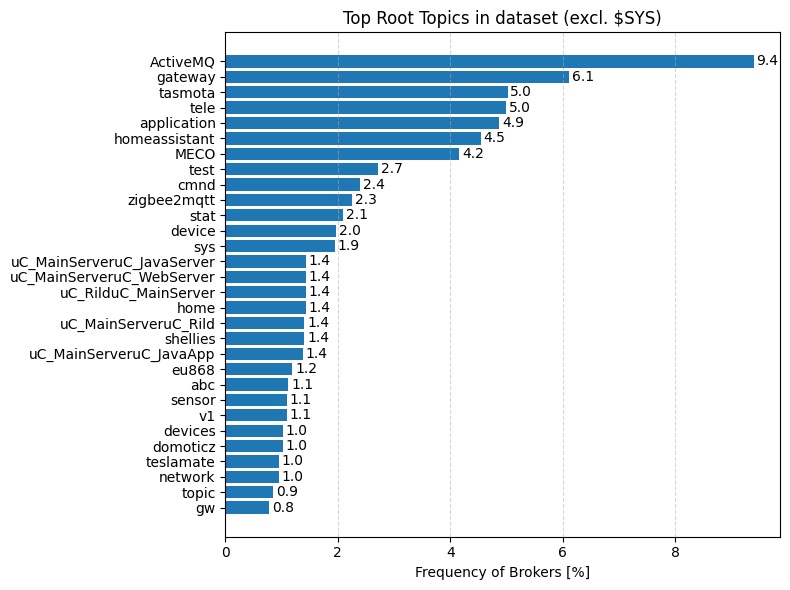

In [10]:
# Bar chart, paper Fig. 7 style
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_roots['root'][::-1], top_roots['pct_brokers'][::-1])
for i, v in enumerate(top_roots['pct_brokers'][::-1]):
    ax.text(v + 0.05, i, f"{v:.1f}", va='center')
ax.set_xlabel('Frequency of Brokers [%]')
ax.set_title('Top Root Topics in dataset (excl. $SYS)')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_top_roots.png", dpi=140)
plt.show()

## 4. Top level words (useful for `+` wildcards)

In [11]:
rows = [(name, c, 100*c/total_brokers) for name, c in level_by_broker_counter.most_common(TOP_N)]
top_levels = pd.DataFrame(rows, columns=['level_word', 'n_brokers', 'pct_brokers'])
top_levels.to_csv(OUT_DIR / "top_level_words.csv", index=False)
top_levels

,level_word,n_brokers,pct_brokers
0,state,609,14.475874
1,status,599,14.238174
2,1,428,10.173520
3,config,425,10.102211
4,Topic,398,9.460423
5,event,398,9.460423
6,ActiveMQ,395,9.389113
7,Advisory,395,9.389113
8,$SYS,395,9.389113
9,Consumer,393,9.341574


## 5. Topic depth and length distribution (CDF)

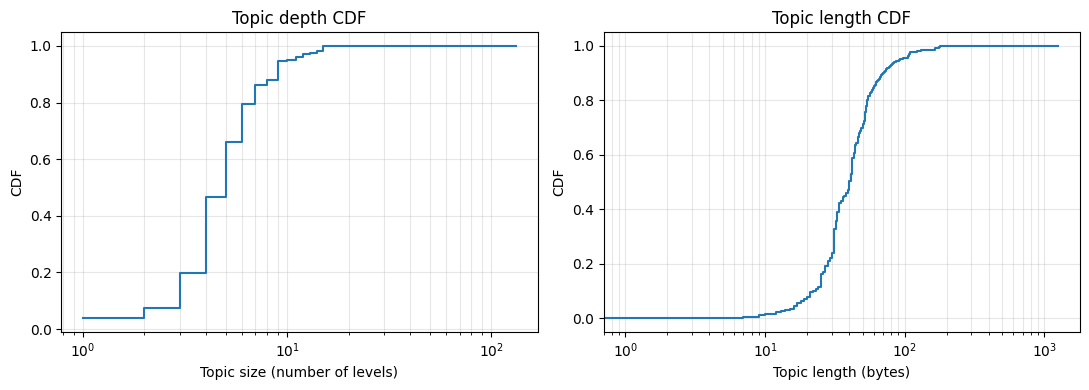

Depth percentiles : {25: 4, 50: 5, 75: 6, 90: 9, 95: 10, 99: 15}
Length percentiles: {25: 31, 50: 40, 75: 52, 90: 70, 95: 92, 99: 166}


In [12]:
def cdf_from_counter(counter):
    items = sorted(counter.items())
    xs = np.array([k for k,_ in items])
    ys = np.cumsum([c for _,c in items], dtype=float)
    ys /= ys[-1]
    return xs, ys

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x, y = cdf_from_counter(depth_counter)
axes[0].step(x, y, where='post')
axes[0].set_xscale('log')
axes[0].set_xlabel('Topic size (number of levels)')
axes[0].set_ylabel('CDF')
axes[0].set_title('Topic depth CDF')
axes[0].grid(True, which='both', alpha=0.3)

x, y = cdf_from_counter(length_counter)
axes[1].step(x, y, where='post')
axes[1].set_xscale('log')
axes[1].set_xlabel('Topic length (bytes)')
axes[1].set_ylabel('CDF')
axes[1].set_title('Topic length CDF')
axes[1].grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_topic_depth_length.png", dpi=140)
plt.show()

def percentiles_from_counter(counter, qs=(25,50,75,90,95,99)):
    total = sum(counter.values())
    out = {}
    cum = 0
    targets = {q: int(total*q/100) for q in qs}
    for k in sorted(counter):
        cum += counter[k]
        for q in list(targets):
            if cum >= targets[q]:
                out[q] = k
                del targets[q]
        if not targets:
            break
    return out

print("Depth percentiles :", percentiles_from_counter(depth_counter))
print("Length percentiles:", percentiles_from_counter(length_counter))

## 6. Building the subscription list

Constraint: **no root-level `#`**. So no subscribe to `#`. Instead we can:
1. Subscribe to the most frequent **root topics** with `<root>/#` (wildcard only from the
   second level on → allowed on the public brokers).
2. Add some mixed single-level filters like `+/<word>/#` to test intermediate structures.

We build a list of ~60 topic filters.

In [13]:
# Reject suspicious roots (pure numbers or clearly non-standard tokens)
def is_clean(token):
    return bool(re.match(r'^[A-Za-z][A-Za-z0-9_\-]{1,30}$', token))

ROOTS_TO_USE = [r for r,_ in root_by_broker_counter.most_common(80) if is_clean(r)][:50]
LEVELS_TO_USE = [w for w,_ in level_by_broker_counter.most_common(50) if is_clean(w)][:15]

subscription_filters = []
# 1) root wildcard
for r in ROOTS_TO_USE:
    subscription_filters.append(f"{r}/#")

# 2) a few mixed patterns (e.g. +/state, +/status, +/config, +/event ...)
for w in ["state", "status", "config", "event", "sensor", "data", "temperature", "command"]:
    if w in LEVELS_TO_USE:
        subscription_filters.append(f"+/{w}")
        subscription_filters.append(f"+/+/{w}")

# 3) a few very common specific topics (Tasmota / HomeAssistant / Zigbee2MQTT)
subscription_filters += [
    "tele/+/+", "stat/+/+", "cmnd/+/+",          # Tasmota
    "homeassistant/#",                           # Home Assistant discovery
    "zigbee2mqtt/+", "zigbee2mqtt/+/+",          # Zigbee2MQTT
    "shellies/+/+/+",                            # Shelly devices
    "$SYS/broker/version",                       # diagnostic info only
    "$SYS/broker/clients/connected",
]

# Dedup, keep order
seen = set(); subs = []
for f in subscription_filters:
    if f not in seen:
        seen.add(f); subs.append(f)

print(f"Number of subscribe filters generated: {len(subs)}")
for s in subs[:25]:
    print(" ", s)
print("  ...")

Number of subscribe filters generated: 68
  ActiveMQ/#
  gateway/#
  tasmota/#
  tele/#
  application/#
  homeassistant/#
  MECO/#
  test/#
  cmnd/#
  zigbee2mqtt/#
  stat/#
  device/#
  sys/#
  uC_MainServeruC_JavaServer/#
  uC_MainServeruC_WebServer/#
  uC_RilduC_MainServer/#
  home/#
  uC_MainServeruC_Rild/#
  shellies/#
  uC_MainServeruC_JavaApp/#
  eu868/#
  abc/#
  sensor/#
  v1/#
  devices/#
  ...


In [14]:
# Export the list for the collector. QoS=2 (required) for every subscribe.
payload = {
    "qos": 2,
    "topics": subs
}
with open(OUT_DIR / "subscription_list.json", "w") as fh:
    json.dump(payload, fh, indent=2)
print("Saved:", OUT_DIR / "subscription_list.json")

Saved: outputs/subscription_list.json


## 7. Final sanity check

In [15]:
import pandas as pd
summary = pd.Series({
    "# brokers analyzed":  total_brokers,
    "# distinct topics":   len(all_topics_counter),
    "# distinct roots":    len(root_by_broker_counter),
    "median topic depth":  percentiles_from_counter(depth_counter)[50],
    "median topic length": percentiles_from_counter(length_counter)[50],
    "# subscribe filters": len(subs),
})
print(summary.to_string())

# brokers analyzed        4207
# distinct topics      2818854
# distinct roots        184635
median topic depth           5
median topic length         40
# subscribe filters         68
